In [ ]:
from sklearn.datasets import make_blobs
X,y = make_blobs(n_samples=100,
                 n_features=2,
                 centers=5,
                 random_state=10)

In [ ]:
from sklearn.cluster import KMeans
kmc = KMeans(n_clusters=5,
             init='random',
             n_init=10,
             max_iter=100,
             random_state=102)
kmc.fit(X)
label_kmc= kmc.labels_
print(label_kmc)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
kmc_columns = ['kmc_comp1','kmc_comp2']
X_kmc_df = pd.DataFrame(X,columns=kmc_columns)
X_kmc_df['target'] = y
X_kmc_df['label_kmc'] = label_kmc
df = X_kmc_df
markers=['o','x','^','s','*']
for i, mark in enumerate(markers):
    df_i = df[df['label_kmc']==i]
    target_i = i
    X1 = df_i['kmc_comp1']
    X2 = df_i['kmc_comp2']
    plt.scatter(X1,X2,marker=mark,label=target_i)
plt.xlabel('kmc_component1')
plt.ylabel('kmc_component2')
plt.legend()
plt.show()
    

In [ ]:
from sklearn.cluster import KMeans
seed_lst = [1,10,100,1000,10000]
model_lst = []
for s in seed_lst:
    kmc = KMeans(n_clusters=5,
             init='random',
             n_init=10,
             max_iter=100,
             random_state=s)
    model_lst.append(kmc)
    
    kmc.fit(X)
    label_kmc= kmc.labels_
    kmc_columns = ['kmc_comp1','kmc_comp2']
    X_kmc_df = pd.DataFrame(X,columns=kmc_columns)
    X_kmc_df['target'] = y
    X_kmc_df['label_kmc'] = label_kmc
    df = X_kmc_df
    markers=['o','x','^','s','*']
    for i, mark in enumerate(markers):
        df_i = df[df['label_kmc']==i]
        target_i = i
        X1 = df_i['kmc_comp1']
        X2 = df_i['kmc_comp2']
        plt.scatter(X1,X2,marker=mark,label=target_i)
    plt.title(f"seed : {s}")
    plt.xlabel('kmc_component1')
    plt.ylabel('kmc_component2')
    plt.legend()
    plt.show()

    

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
seed_lst = [1,10,100,1000,10000]
noise_lst = [0.01,0.05,0.1,0.5,1]
for s in seed_lst:
    for n in noise_lst:
        X,y = make_moons(n_samples=300,noise=n,random_state=s)
        dbs = DBSCAN(eps=0.2)
        dbs.fit(X)
        label_dbs = dbs.labels_
        dbs_columns = ['dbs_comp1','dbs_comp2']
        X_dbs_df = pd.DataFrame(X,columns=dbs_columns)
        X_dbs_df['target'] = y
        X_dbs_df['label_dbs'] = label_dbs
        df = X_dbs_df
        markers=['o','x']
        for i, mark in enumerate(markers):
            df_i = df[df['label_dbs']==i]
            target_i = i
            X1 = df_i['dbs_comp1']
            X2 = df_i['dbs_comp2']
            plt.scatter(X1,X2,marker=mark,label=target_i)
        plt.title(f"noise : {n} seed : {s}")
        plt.xlabel('dbs_component1')
        plt.ylabel('dbs_component2')
        plt.legend()
        plt.show()

    

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
import pandas as pd
import matplotlib.pyplot as plt
seed_lst = [1,10,100,1000,10000]
noise_lst = [0.01,0.05,0.1,0.5,1]
for s in seed_lst:
    
    X,y = make_blobs(n_samples=200,n_features=2,centers=2,random_state=s)
    gmm = GaussianMixture(n_components=2,random_state=s)
    gmm.fit(X)
    label_gmm = gmm.predict(X)
    gmm_columns = ['gmm_comp1','gmm_comp2']
    X_gmm_df = pd.DataFrame(X,columns=gmm_columns)
    X_gmm_df['target'] = y
    X_gmm_df['label_gmm'] = label_gmm
    df = X_gmm_df
    markers=['o','x']
    for i, mark in enumerate(markers):
        df_i = df[df['label_gmm']==i]
        target_i = i
        X1 = df_i['gmm_comp1']
        X2 = df_i['gmm_comp2']
        plt.scatter(X1,X2,marker=mark,label=target_i)
    plt.title(f"seed : {s}")
    plt.xlabel('gmm_component1')
    plt.ylabel('gmm_component2')
    plt.legend()
    plt.show()



In [ ]:
from sklearn import svm
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./data/wine_data.csv')
X = df[['Alcohol']]
X2 = df[['Alcohol','Magesium']]
nu_lst = [0.01,0.05,0.1,0.5,1]
for n in nu_lst:
    clf = svm.OneClassSVM(gamma='auto',nu=n)
    clf2 = svm.OneClassSVM(gamma='auto',nu=n)
    clf.fit(X)
    clf2.fit(X2)
    pred1 = clf.predict(X)
    pred2 = clf2.predict(X2)

    plt.scatter(X,pred1)
    plt.title(f"seed : {s}")
    plt.xlabel('real')
    plt.ylabel('predict')
    plt.legend()
    plt.show()



In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./data/wine_data.csv')
X2 = df[['Alcohol','Magesium']]
n_neighbors = [1,2,3,5,10]
for n in n_neighbors:
    clf2 = LocalOutlierFactor(n_neighbors=n)
    clf2.fit(X2)
    pred2 = clf2.fit_predict(X2)
    print(silhouette_score(X2,pred2))

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./data/wine_data.csv')
X2 = df[['Alcohol','Magesium']]
seed = [1,2,3,5,10,50,2026]
for s in seed:
    clf2 = IsolationForest(random_state=s)
    clf2.fit(X2)
    pred2 = clf2.predict(X2)
    print(silhouette_score(X2,pred2))

In [ ]:
df.columns

In [ ]:
features = ['Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline']
target = 'class'
X = df[features]
Y = df[target]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
Xtn,Xte,Ytn,Yte = train_test_split(X,Y,random_state=0)
std = StandardScaler()
Xtns=std.fit_transform(Xtn)
Xtes=std.transform(Xte)
pca = PCA(n_components=2)
pca.fit(Xtns)
Xtn_pca = pca.transform(Xtns)
Xte_pca = pca.transform(Xtes)
print(pca.components_)
# 라벨 적용 PCA 플랏
df = 

df_0 = df[df['target']==0]
df_1 = df[df['target']==1]
df_2 = df[df['target']==2]

X_11 = df_0['pca_comp1']
X_12 = df_1['pca_comp1']
X_13 = df_2['pca_comp1']

X_21 = df_0['pca_comp2']
X_22 = df_1['pca_comp2']
X_23 = df_2['pca_comp2']

target_0 = 0
target_1 = 1
target_2 = 2

plt.figure(figsize=(15, 8))
plt.scatter(X_11, X_21, marker='o', label=target_0)
plt.scatter(X_12, X_22, marker='x', label=target_1)
plt.scatter(X_13, X_23, marker='^', label=target_2)
plt.xlabel('pca_component1')
plt.ylabel('pca_component2')
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X_tn, X_te, Y_tn, Y_te = train_test_split(X,Y,random_state=0)
std_scale = StandardScaler()
std_scale.fit(X_tn)
X_tn_std = std_scale.transform(X_tn)
X_te_std = std_scale.transform(X_te)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(X_tn_std,Y_tn)
pred = lda.predict(X_te_std)
lda_columns = ['lda_c1','lda_c2']
X_tn_lda = lda.transform(X_tn_std)
X_te_lda = lda.transform(X_te_std)
X_tn_lda_df = pd.DataFrame(X_tn_lda, columns=lda_columns)
X_tn_lda_df['target'] = Y_tn.reset_index(drop=True)
from sklearn.ensemble import RandomForestClassifier
clf_rf_lda = RandomForestClassifier(max_depth=2,random_state=0)
clf_rf_lda.fit(X_tn_lda,Y_tn)
pred_rf = clf_rf_lda.predict(X_te_lda)
from sklearn.metrics import accuracy_score
acc = accuracy_score(Y_te,pred_rf)
print(acc)
print(lda.intercept_)
print(lda.coef_)

In [1]:
import numpy as np
import pandas as pd
import statsmodels
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
df = pd.read_csv('./data/air_quality_uci.csv',encoding='cp949')
df['DateTime'] = df['Date'] + ' ' + df['Time']
df['DateTimeIndex'] = pd.to_datetime(df['DateTime'])
df = df.set_index(keys=['DateTimeIndex'])


In [2]:
train_ratio = 0.997
n = len(df)
n_train = int(n*train_ratio)
df_train = df[:n_train]
df_test = df[n_train:]
features = ['T','AH']
target = 'PT08_S4'
X_tn = df_train[features]
X_te = df_test[features]
Y_tn = df_train[target]
Y_te = df_test[target]

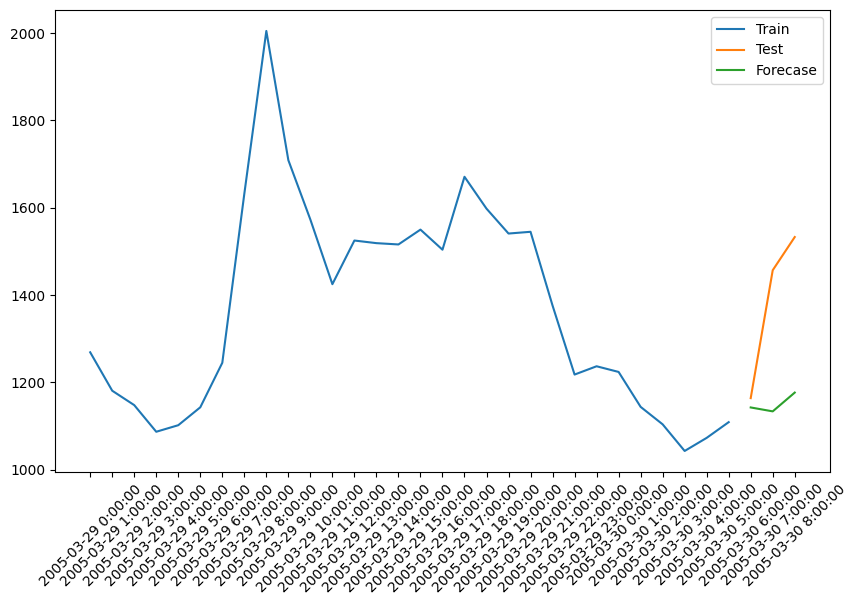

In [3]:
X_tn = sm.add_constant(X_tn)
X_te = sm.add_constant(X_te)
ols_reg = sm.OLS(endog=Y_tn, exog=X_tn)
# ols_model = ols_reg.fit()
ols_model = ols_reg.fit_regularized(method='elastic_net', alpha=0.1, L1_wt=0.7)
# ols_model.summary()
ols_model.predict()
y_hat = ols_model.predict(X_te)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(df_train['DateTime'][-30:],df_train['PT08_S4'][-30:],label='Train')
plt.plot(df_test['DateTime'],Y_te,label='Test')
plt.plot(df_test['DateTime'],y_hat,label='Forecase')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [4]:
X_train = X_tn.asfreq('h')
Y_train = Y_tn.asfreq('h')
X_test = X_te.asfreq('h')
Y_test = Y_te.asfreq('h')

In [5]:
sarimax = ARIMA(endog=Y_train,exog=X_train,order=(2,1,1),seasonal_order=(0,1,1,24))
sarimax_fit = sarimax.fit()

c:\Users\User\miniconda3\envs\ml4\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [6]:
sarimax_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:                          PT08_S4   No. Observations:                  997
Model:             ARIMA(2, 1, 1)x(0, 1, 1, 24)   Log Likelihood               -5803.984
Date:                          Tue, 09 Jun 2026   AIC                          11623.969
Time:                                  14:38:04   BIC                          11663.004
Sample:                              02-16-2005   HQIC                         11638.825
                                   - 03-30-2005                                         
Covariance Type:                            opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002   1.63e+04    1.4e-08      1.000    -3.2e+04     3.2e+04
T            -13.1660      3.166     -4.158      0.000     -19.372      -6.960
AH            21.3762      3.768      5.673      0.000      13.991      28.762
ar.L1          0.8271      0.034     24.011      0.000       0.760       0.895
ar.L2         -0.1561      0.032     -4.874      0.000      -0.219      -0.093
ma.L1         -0.8969      0.027    -33.516      0.000      -0.949      -0.844
ma.S.L24      -0.9195      0.012    -79.484      0.000      -0.942      -0.897
sigma2      8597.9764    276.682     31.075      0.000    8055.689    9140.263
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               221.32
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               1.83   Skew:                             0.26
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.28
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [7]:
sarimax_fit.predict()

DateTimeIndex
2005-02-16 17:00:00     -98.207381
2005-02-16 18:00:00    1020.633741
2005-02-16 19:00:00    1113.375882
2005-02-16 20:00:00    1303.589759
2005-02-16 21:00:00    1549.578398
                          ...     
2005-03-30 01:00:00    1200.365185
2005-03-30 02:00:00    1128.623745
2005-03-30 03:00:00    1088.825262
2005-03-30 04:00:00    1063.924955
2005-03-30 05:00:00    1101.287251
Freq: h, Name: predicted_mean, Length: 997, dtype: float64

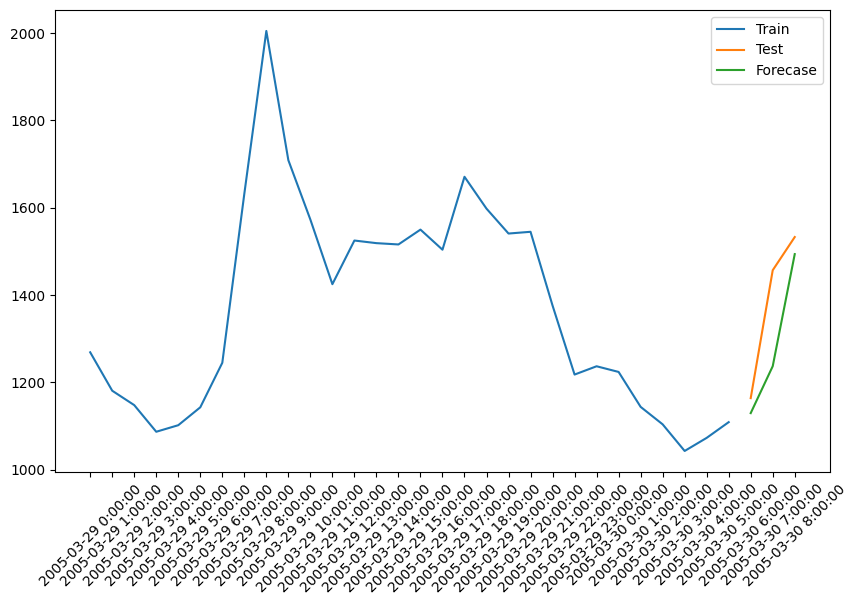

In [8]:
y_hat = sarimax_fit.forecast(steps=len(X_test),exog=X_test)
plt.figure(figsize=(10,6))
plt.plot(df_train['DateTime'][-30:],df_train['PT08_S4'][-30:],label='Train')
plt.plot(df_test['DateTime'],Y_te,label='Test')
plt.plot(df_test['DateTime'],y_hat,label='Forecase')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [9]:
from arch import arch_model
arch = arch_model(Y_train,vol='ARCH',p=1)
arch_fit = arch.fit()
arch_fit.forecast()
pred_var = arch_fit.forecast(horizon=len(Y_test))
pred_var.variance.values
pred_arch = np.sqrt(pred_var.variance.values[0])
pred_arch

Iteration:      1,   Func. Count:      5,   Neg. LLF: 6798.571442628256
Iteration:      2,   Func. Count:     10,   Neg. LLF: 6796.203793748537
Iteration:      3,   Func. Count:     14,   Neg. LLF: 6793.586704442394
Iteration:      4,   Func. Count:     18,   Neg. LLF: 6787.867847819874
Iteration:      5,   Func. Count:     22,   Neg. LLF: 6787.523303989077
Iteration:      6,   Func. Count:     26,   Neg. LLF: 6787.513589853928
Iteration:      7,   Func. Count:     30,   Neg. LLF: 6787.513528099284
Iteration:      8,   Func. Count:     34,   Neg. LLF: 6787.51352820889
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6787.513527827316
            Iterations: 8
            Function evaluations: 35
            Gradient evaluations: 8


c:\Users\User\miniconda3\envs\ml4\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.448e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


array([122.23918568, 167.27300649, 198.48792818])

In [10]:
garch = arch_model(Y_train,vol='GARCH',p=15,q=15)
garch_fit = garch.fit()
pred_var = garch_fit.forecast(horizon=len(Y_test))
pred_garch = np.sqrt(pred_var.variance.values[0])
pred_garch

c:\Users\User\miniconda3\envs\ml4\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.448e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


Iteration:      1,   Func. Count:     34,   Neg. LLF: 6810.873725874561
Iteration:      2,   Func. Count:     67,   Neg. LLF: 6819.022944446615
Iteration:      3,   Func. Count:    101,   Neg. LLF: 7300.496351124351
Iteration:      4,   Func. Count:    135,   Neg. LLF: 7138.455501386903
Iteration:      5,   Func. Count:    170,   Neg. LLF: 7570.147363635051
Iteration:      6,   Func. Count:    204,   Neg. LLF: 6802.949248628796
Iteration:      7,   Func. Count:    238,   Neg. LLF: 6801.330062469369
Iteration:      8,   Func. Count:    272,   Neg. LLF: 6795.403948401796
Iteration:      9,   Func. Count:    306,   Neg. LLF: 6794.913772681395
Iteration:     10,   Func. Count:    339,   Neg. LLF: 6794.327314158953
Iteration:     11,   Func. Count:    372,   Neg. LLF: 6791.208215346236
Iteration:     12,   Func. Count:    405,   Neg. LLF: 6788.746810110857
Iteration:     13,   Func. Count:    438,   Neg. LLF: 6788.502298833479
Iteration:     14,   Func. Count:    471,   Neg. LLF: 6788.47871

array([211.85798471, 273.29845182, 317.11811887])

In [11]:
sarimax = ARIMA(endog=Y_train,exog=X_train,order=(1,1,0),seasonal_order=(0,1,1,12))
sarimax_fit = sarimax.fit()
sarimax_residual = sarimax_fit.resid
sarimax_residual

DateTimeIndex
2005-02-16 17:00:00    1018.205233
2005-02-16 18:00:00      97.451023
2005-02-16 19:00:00     189.196722
2005-02-16 20:00:00     240.979642
2005-02-16 21:00:00    -249.636427
                          ...     
2005-03-30 01:00:00     -66.863187
2005-03-30 02:00:00     -11.840562
2005-03-30 03:00:00     -32.497276
2005-03-30 04:00:00      36.884228
2005-03-30 05:00:00      17.090232
Freq: h, Length: 997, dtype: float64

In [12]:
adjusted_constant=0.1
adj_sarimax_residual = sarimax_residual*adjusted_constant
adj_sarimax_residual.describe()

count    997.000000
mean       0.071086
std       11.860978
min      -54.038587
25%       -5.485273
50%       -0.415039
75%        4.898291
max      101.820523
dtype: float64

In [14]:
garch = arch_model(adj_sarimax_residual,vol='GARCH',p=20,q=20)
garch_fit = garch.fit()
pred_mu = sarimax_fit.forecast(steps=len(X_test),exog=X_test)
pred_mu

Iteration:      1,   Func. Count:     44,   Neg. LLF: 3830.8142462897813
Iteration:      2,   Func. Count:     88,   Neg. LLF: 3803.5375129580243
Iteration:      3,   Func. Count:    132,   Neg. LLF: 3943.2464804068168
Iteration:      4,   Func. Count:    177,   Neg. LLF: 4083.039763012124
Iteration:      5,   Func. Count:    222,   Neg. LLF: 3875.6081429362794
Iteration:      6,   Func. Count:    266,   Neg. LLF: 4017.188404386123
Iteration:      7,   Func. Count:    310,   Neg. LLF: 4070.2596604939927
Iteration:      8,   Func. Count:    354,   Neg. LLF: 3805.9664845743473
Iteration:      9,   Func. Count:    398,   Neg. LLF: 3905.2873255962913
Iteration:     10,   Func. Count:    442,   Neg. LLF: 3835.6721399602766
Iteration:     11,   Func. Count:    486,   Neg. LLF: 3802.8019940655977
Iteration:     12,   Func. Count:    530,   Neg. LLF: 4084.7146430457415
Iteration:     13,   Func. Count:    574,   Neg. LLF: 5545.856256975454
Iteration:     14,   Func. Count:    618,   Neg. LLF: 

2005-03-30 06:00:00    1183.689368
2005-03-30 07:00:00    1285.022292
2005-03-30 08:00:00    1414.852544
Freq: h, Name: predicted_mean, dtype: float64

In [16]:
adj_forecase_residual = garch_fit.forecast(horizon=len(Y_test))
adj_forecase_residual

In [17]:
adj_forecase_residual.variance.values

array([[141.71155907, 204.12570364, 192.99443638]])

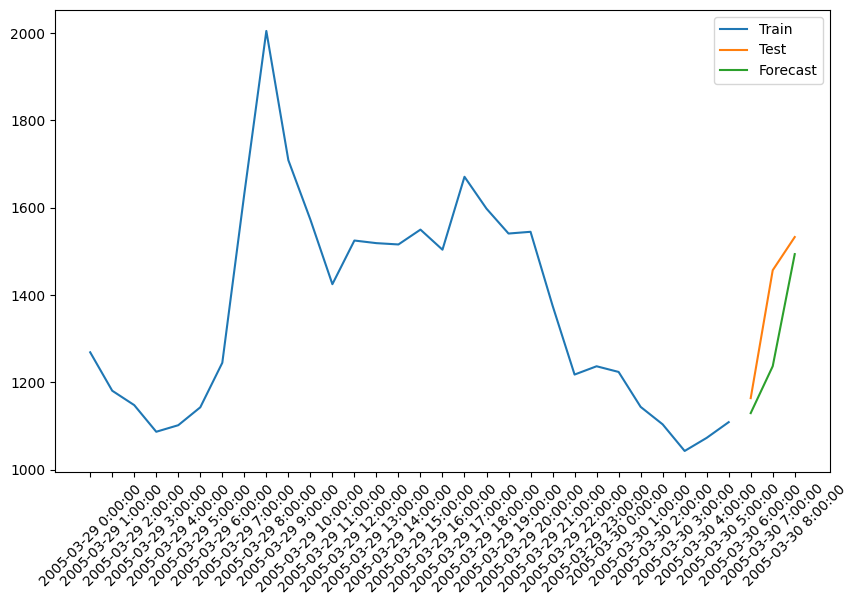

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(df_train['DateTime'][-30:], df_train['PT08_S4'][-30:], label='Train')
plt.plot(df_test['DateTime'], Y_test, label='Test')
plt.plot(df_test['DateTime'], y_hat, label='Forecast')
plt.xticks(rotation=45)
plt.legend()
plt.show()


In [47]:
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('./data/air_quality_uci.csv',encoding='cp949')
df['DateTime'] = df['Date'] + ' ' + df['Time']
df['ds'] = df['DateTime']
df['y'] = df['PT08_S4']
df = df[['ds','T','AH','y']]

In [48]:
train_ratio = 0.997
n = len(df)
n_train = int(n*train_ratio)
df_train = df[:n_train]
df_test = df[n_train:]
scaler = StandardScaler()
df_train[['T', 'AH']] = scaler.fit_transform(df_train[['T', 'AH']])

In [49]:
# model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model = Prophet(
    yearly_seasonality=True, 
    weekly_seasonality=True, 
    daily_seasonality=False,
    changepoint_prior_scale=0.05, # 기본값 0.05 -> 0.01로 줄이면 모델이 덜 민감해짐
    seasonality_mode='additive'    # 데이터에 따라 'multiplicative'가 나을 수도 있음
)
regressor_col = ['T','AH']
for col in regressor_col:
    model.add_regressor(col)

In [50]:
model.fit(df_train)

15:48:47 - cmdstanpy - INFO - Chain [1] start processing
15:48:47 - cmdstanpy - INFO - Chain [1] done processing
15:48:47 - cmdstanpy - ERROR - Chain [1] error: code '3221225781' 
Optimization terminated abnormally. Falling back to Newton.
15:48:47 - cmdstanpy - INFO - Chain [1] start processing
15:48:47 - cmdstanpy - INFO - Chain [1] done processing
15:48:47 - cmdstanpy - ERROR - Chain [1] error: code '3221225781' 


RuntimeError: Error during optimization! Command 'C:\Users\User\miniconda3\envs\ml4\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=75431 data file=C:\Users\User\AppData\Local\Temp\tmpb1gn7g04\6m_1xqly.json init=C:\Users\User\AppData\Local\Temp\tmpb1gn7g04\u22n4mx7.json output file=C:\Users\User\AppData\Local\Temp\tmpb1gn7g04\prophet_model3j06ixjh\prophet_model-20260609154847.csv method=optimize algorithm=newton iter=10000' failed: 